# **Credit Risk Modelling**

## **Business Understanding**


Multifinance companies want to improve the accuracy of assessing potential borrowers' credit risk to reduce the potential for default and support more informed lending decisions. Leveraging historical loan data, companies are working to build machine learning models capable of identifying high- and low-risk borrowers.




### **Business Problem**
Companies face several challenges, including:

* Difficulty identifying potential borrowers who may default.
* The risk of losses resulting from lending to unworthy customers.
* The need for a more accurate, data-driven credit risk prediction system.




### **Project Goals**

The goal of this project is to develop a machine learning model to predict credit risk based on historical loan data, thereby assisting companies in:

* Identifying potential borrowers at risk of default.
* Supporting a more accurate loan approval process.
* Reducing the risk of losses due to non-performing loans.

## **Data Understanding**

### **Import Library**

In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

In [48]:
df = pd.read_csv('/content/drive/MyDrive/IDX Internship/loan_data_2007_2014.csv')

/tmp/ipykernel_1186/74018446.py:1: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/IDX Internship/loan_data_2007_2014.csv')


In [49]:
pd.set_option('display.max_column', None)
df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**in this dataset has 17 columns and 466285 rows**

### **Checking Missing Value, Duplicate Data and Statistic Descriptive**

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

In [51]:
print(df.duplicated().sum())

0


In [52]:
pd.set_option('display.max_rows', None)
missing = pd.DataFrame({
    'Missing Value': df.isna().sum(),
    'Percentage (%)': (df.isna().sum()/len(df)*100).round(2)
}).sort_values(by='Missing Value', ascending=False)

print(missing.to_string())

                             Missing Value  Percentage (%)
max_bal_bc                          466285          100.00
open_rv_24m                         466285          100.00
inq_fi                              466285          100.00
open_rv_12m                         466285          100.00
il_util                             466285          100.00
mths_since_rcnt_il                  466285          100.00
total_bal_il                        466285          100.00
open_il_24m                         466285          100.00
open_il_12m                         466285          100.00
open_il_6m                          466285          100.00
open_acc_6m                         466285          100.00
dti_joint                           466285          100.00
annual_inc_joint                    466285          100.00
verification_status_joint           466285          100.00
all_util                            466285          100.00
inq_last_12m                        466285          100.

Missing value


In [53]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,466285.0,2.331420e+05,1.346050e+05,0.00,1.165710e+05,2.331420e+05,3.497130e+05,4.662840e+05
id,466285.0,1.307973e+07,1.089371e+07,54734.00,3.639987e+06,1.010790e+07,2.073121e+07,3.809811e+07
member_id,466285.0,1.459766e+07,1.168237e+07,70473.00,4.379705e+06,1.194108e+07,2.300154e+07,4.086083e+07
loan_amnt,466285.0,1.431728e+04,8.286509e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt,466285.0,1.429180e+04,8.274371e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt_inv,466285.0,1.422233e+04,8.297638e+03,0.00,8.000000e+03,1.200000e+04,1.995000e+04,3.500000e+04
int_rate,466285.0,1.382924e+01,4.357587e+00,5.42,1.099000e+01,1.366000e+01,1.649000e+01,2.606000e+01
installment,466285.0,4.320612e+02,2.434855e+02,15.67,2.566900e+02,3.798900e+02,5.665800e+02,1.409990e+03
annual_inc,466281.0,7.327738e+04,5.496357e+04,1896.00,4.500000e+04,6.300000e+04,8.896000e+04,7.500000e+06
dti,466285.0,1.721876e+01,7.851121e+00,0.00,1.136000e+01,1.687000e+01,2.278000e+01,3.999000e+01


In [54]:
df.describe(include='object').T

,count,unique,top,freq
term,466285,2,36 months,337953
grade,466285,7,B,136929
sub_grade,466285,35,B3,31686
emp_title,438697,205475,Teacher,5399
emp_length,445277,11,10+ years,150049
home_ownership,466285,6,MORTGAGE,235875
verification_status,466285,3,Verified,168055
issue_d,466285,91,Oct-14,38782
loan_status,466285,9,Current,224226
pymnt_plan,466285,2,n,466276


### **Handling Missing Value, Change Data Type and Handling Relevant Column**

#### **Missing Value Handling**

In [55]:
#handling missing value
# Hitung persentase missing value
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Kolom yang memiliki missing value lebih dari 1%
cols_to_drop = missing_percentage[missing_percentage > 1].index

# Hapus kolom
df1 = df.drop(columns=cols_to_drop)

print(f"Jumlah kolom yang dihapus: {len(cols_to_drop)}")
print(cols_to_drop.tolist())

Jumlah kolom yang dihapus: 27
['emp_title', 'emp_length', 'desc', 'mths_since_last_delinq', 'mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m']


In [56]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 48 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Unnamed: 0                  466285 non-null  int64  
 1   id                          466285 non-null  int64  
 2   member_id                   466285 non-null  int64  
 3   loan_amnt                   466285 non-null  int64  
 4   funded_amnt                 466285 non-null  int64  
 5   funded_amnt_inv             466285 non-null  float64
 6   term                        466285 non-null  object 
 7   int_rate                    466285 non-null  float64
 8   installment                 466285 non-null  float64
 9   grade                       466285 non-null  object 
 10  sub_grade                   466285 non-null  object 
 11  home_ownership              466285 non-null  object 
 12  annual_inc                  466281 non-null  float64
 13  verification_s

In [57]:
df2 = df1.dropna().copy()
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
Index: 465401 entries, 0 to 466284
Data columns (total 48 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Unnamed: 0                  465401 non-null  int64  
 1   id                          465401 non-null  int64  
 2   member_id                   465401 non-null  int64  
 3   loan_amnt                   465401 non-null  int64  
 4   funded_amnt                 465401 non-null  int64  
 5   funded_amnt_inv             465401 non-null  float64
 6   term                        465401 non-null  object 
 7   int_rate                    465401 non-null  float64
 8   installment                 465401 non-null  float64
 9   grade                       465401 non-null  object 
 10  sub_grade                   465401 non-null  object 
 11  home_ownership              465401 non-null  object 
 12  annual_inc                  465401 non-null  float64
 13  verification_status

#### **Data Type**

In [58]:
#ubah tipe data yang salah
# =========================
# DATETIME
# =========================
date_columns = [
    'issue_d',
    'earliest_cr_line',
    'last_pymnt_d',
    'last_credit_pull_d'
]

for col in date_columns:
    if col in df.columns:
        df2[col] = pd.to_datetime(df2[col], format='%b-%y', errors='coerce')

# =========================
# TERM
# "36 months" -> 36
# =========================
if 'term' in df.columns:
    df2['term'] = (
        df['term']
        .str.replace(' months', '', regex=False)
        .astype('Int64')
    )

# =========================
# EMP_LENGTH
# "10+ years" -> 10
# "< 1 year" -> 0
# "3 years" -> 3
# =========================
#if 'emp_length' in df2.columns:
    #df2['emp_length'] = (
        #df2['emp_length']
        #.str.replace(r'\+ years', '', regex=True)
        #.str.replace(r' years', '', regex=True)
        #.str.replace(r' year', '', regex=True)
        #.str.replace('< 1', '0', regex=False)
        #.str.replace('n/a', '', regex=False)
    #)

    #df2['emp_length'] = pd.to_numeric(df2['emp_length'], errors='coerce')

# =========================
# CATEGORY
# =========================
category_columns = [
    'grade',
    'sub_grade',
    'home_ownership',
    'verification_status',
    'loan_status',
    'purpose',
    'initial_list_status',
    'application_type',
    'addr_state',
    'pymnt_plan'
]

for col in category_columns:
    if col in df2.columns:
        df2[col] = df2[col].astype('category')

# =========================
# CEK HASIL
# =========================
df2.info()


<class 'pandas.core.frame.DataFrame'>
Index: 465401 entries, 0 to 466284
Data columns (total 48 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Unnamed: 0                  465401 non-null  int64         
 1   id                          465401 non-null  int64         
 2   member_id                   465401 non-null  int64         
 3   loan_amnt                   465401 non-null  int64         
 4   funded_amnt                 465401 non-null  int64         
 5   funded_amnt_inv             465401 non-null  float64       
 6   term                        465401 non-null  Int64         
 7   int_rate                    465401 non-null  float64       
 8   installment                 465401 non-null  float64       
 9   grade                       465401 non-null  category      
 10  sub_grade                   465401 non-null  category      
 11  home_ownership              465401 non-null 

#### **Handling Relevant Column**

In [59]:
#hapus kolom yang tidak relevan
drop_cols = [
    'Unnamed: 0',
    'id',
    'member_id',
    'url',

    'title',
    'zip_code']
df3 = df2.drop(columns=drop_cols)
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 465401 entries, 0 to 466284
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   loan_amnt                   465401 non-null  int64         
 1   funded_amnt                 465401 non-null  int64         
 2   funded_amnt_inv             465401 non-null  float64       
 3   term                        465401 non-null  Int64         
 4   int_rate                    465401 non-null  float64       
 5   installment                 465401 non-null  float64       
 6   grade                       465401 non-null  category      
 7   sub_grade                   465401 non-null  category      
 8   home_ownership              465401 non-null  category      
 9   annual_inc                  465401 non-null  float64       
 10  verification_status         465401 non-null  category      
 11  issue_d                     465401 non-null 

## **EDA**

#### **Univariat**

##### **Loan Status / Target Variable**

In [60]:
#cek total dari masing masing nilai uniq untuk loan status
df3['loan_status'].value_counts()


,count
loan_status,
Current,224096
Fully Paid,184523
Charged Off,42056
Late (31-120 days),6895
In Grace Period,3144
Does not meet the credit policy. Status:Fully Paid,1913
Late (16-30 days),1217
Default,832
Does not meet the credit policy. Status:Charged Off,725


/tmp/ipykernel_1186/3466575711.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


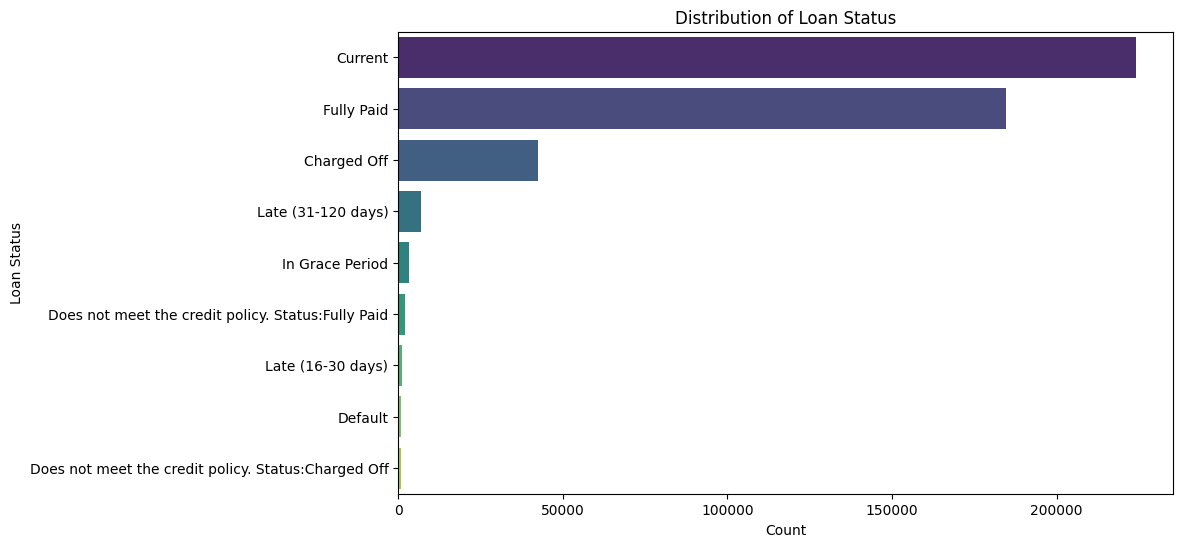

loan_status
Current                                                48.15
Fully Paid                                             39.65
Charged Off                                             9.04
Late (31-120 days)                                      1.48
In Grace Period                                         0.68
Does not meet the credit policy. Status:Fully Paid      0.41
Late (16-30 days)                                       0.26
Default                                                 0.18
Does not meet the credit policy. Status:Charged Off     0.16
Name: proportion, dtype: float64


In [61]:
plt.figure(figsize=(10,6))

order = df3['loan_status'].value_counts().index

sns.countplot(
    y='loan_status',
    data=df,
    order=order,
    palette='viridis'
)

plt.title('Distribution of Loan Status')
plt.xlabel('Count')
plt.ylabel('Loan Status')

plt.show()

loan_status = (
    df3['loan_status']
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

print(loan_status)

* Current loans account for nearly half of the dataset.
* Fully Paid is the second largest category.
* Charged Off represents around 9% of all loans.
* Other statuses contribute only a small proportion

##### **Numerical Features**

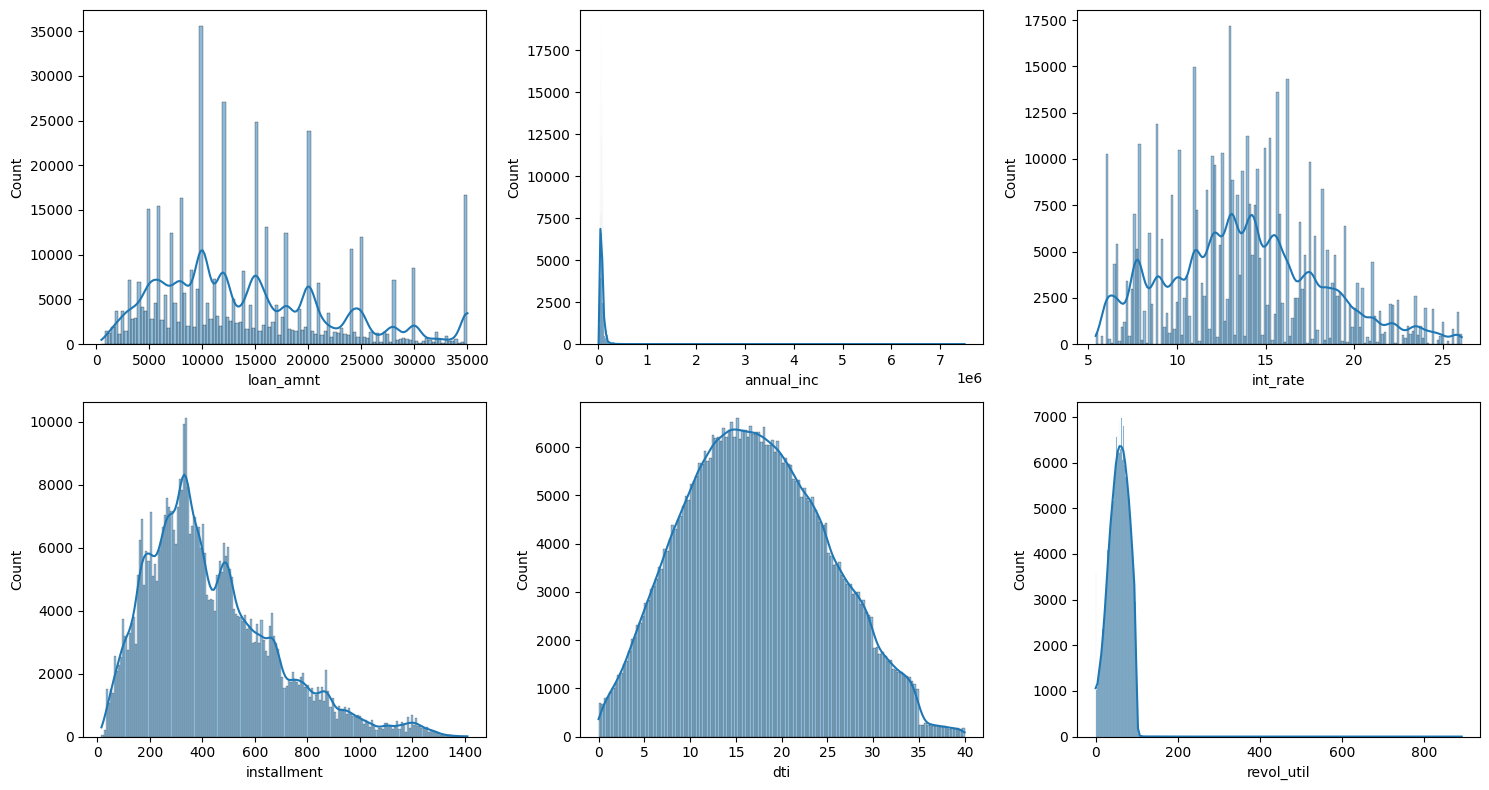

In [62]:
fig, axes = plt.subplots(2,3, figsize=(15,8))

num_cols = [
    'loan_amnt',
    'annual_inc',
    'int_rate',
    'installment',
    'dti',
    'revol_util'
]

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df3[col], kde=True, ax=ax)

plt.tight_layout()

“The numerical features show skewed distributions, particularly in annual income and revolving utilization, indicating the presence of outliers. Most borrowers request loans in the range of 5,000–20,000, with interest rates concentrated between 10%–20%.

##### **Categorical Features**

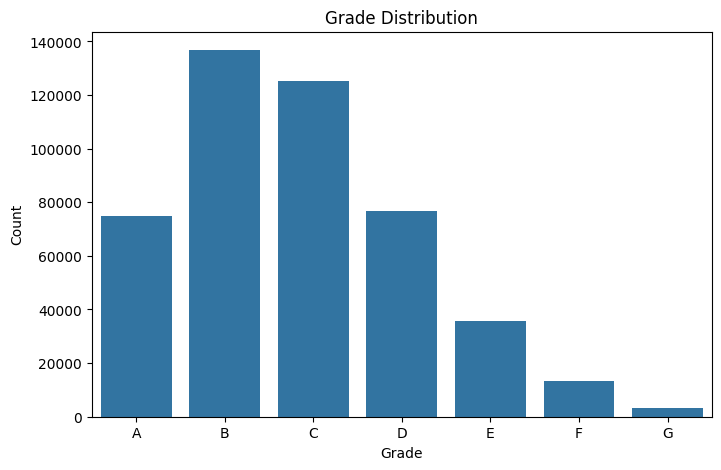

In [63]:


plt.figure(figsize=(8,5))

sns.countplot(
    x='grade',
    data=df3,
    order=sorted(df3['grade'].unique())
)
plt.title('Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.show()

In [64]:
#uniq grade value and percentase
grade_counts = df3['grade'].value_counts(normalize=True).mul(100).round(2)
grade_countsun = df3['grade'].value_counts()
print(grade_counts)
print(grade_countsun)

grade
B    29.39
C    26.88
D    16.48
A    16.07
E     7.65
F     2.83
G     0.71
Name: proportion, dtype: float64
grade
B    136769
C    125081
D     76679
A     74775
E     35620
F     13178
G      3299
Name: count, dtype: int64


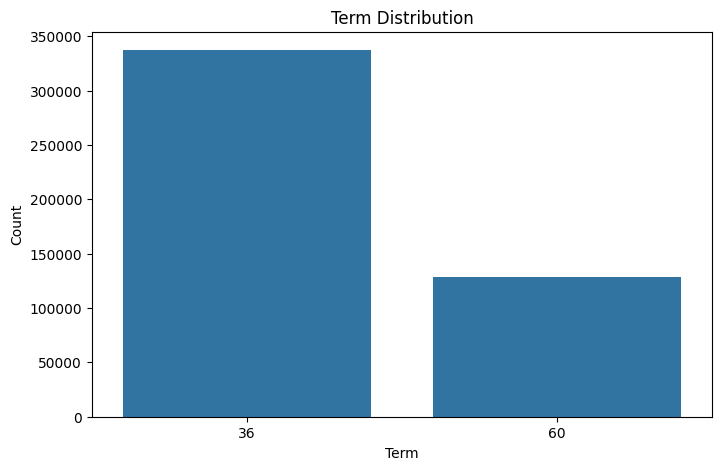

In [65]:
#term
plt.figure(figsize=(8,5))

sns.countplot(
    x='term',
    data=df3
)
plt.title('Term Distribution')
plt.xlabel('Term')
plt.ylabel('Count')
plt.show()

In [66]:
term_counts = df3['term'].value_counts(normalize=True).mul(100).round(2)
term_countsun = df3['term'].value_counts()
print(term_counts)
print(term_countsun)

term
36    72.46
60    27.54
Name: proportion, dtype: Float64
term
36    337249
60    128152
Name: count, dtype: Int64


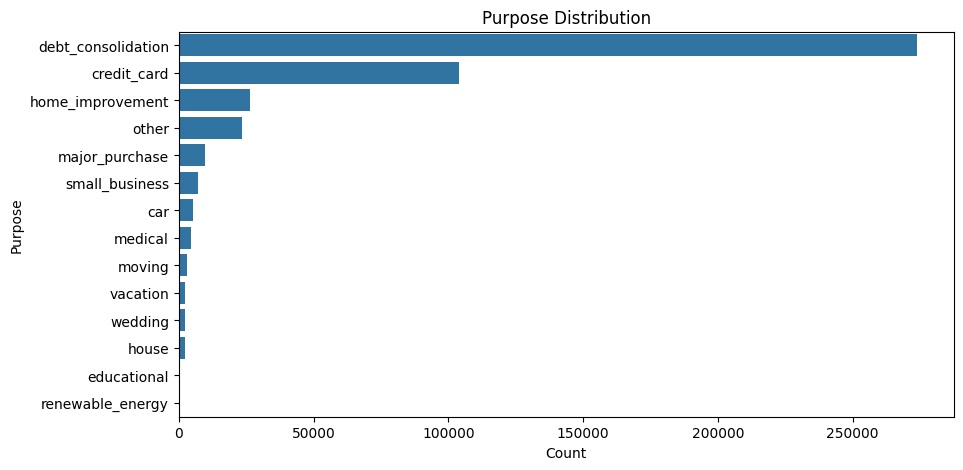

In [67]:
#purpose dibuat x nya jadi y
plt.figure(figsize=(10,5))

sns.countplot(
    y='purpose',
    data=df3,
    order=df3['purpose'].value_counts().index
)
plt.title('Purpose Distribution')
plt.xlabel('Count')
plt.ylabel('Purpose')
plt.show()

In [68]:
purpose_counts = df3['purpose'].value_counts(normalize=True).mul(100).round(2)
purpose_countsun = df3['purpose'].value_counts()
print(purpose_counts)
print(purpose_countsun)

purpose
debt_consolidation    58.83
credit_card           22.36
home_improvement       5.69
other                  5.06
major_purchase         2.10
small_business         1.50
car                    1.15
medical                0.98
moving                 0.64
vacation               0.53
wedding                0.50
house                  0.49
educational            0.09
renewable_energy       0.07
Name: proportion, dtype: float64
purpose
debt_consolidation    273815
credit_card           104053
home_improvement       26461
other                  23548
major_purchase          9791
small_business          6978
car                     5375
medical                 4579
moving                  2982
vacation                2476
wedding                 2328
house                   2262
educational              404
renewable_energy         349
Name: count, dtype: int64


Loan Distribution Analysis
* Grade Distribution: Dominating grades are B (29.39%) and C (26.88%), accounting for more than half of the total loans. Riskier grades (E to G) are very minimal.

* Term Distribution: Shorter-term loans are highly preferred, with 36 months (72.46%) being nearly triple the volume of 60-month loans (27.64%).

* Purpose Distribution: Loan reasons are heavily concentrated. Debt Consolidation (58.83%) and Credit Card (22.36%) make up over 80% of all loan purposes.

Key Takeaway
📊 The typical borrower profile consists of a Grade B/C risk rating, opting for a 36-month term, primarily to consolidate debt or pay off credit cards.

### **Bivariat**

##### **Loan Status After Prepratation**

In [69]:
df4 = df3.copy()
# Status yang digunakan
loan_status_keep = ['Fully Paid', 'Charged Off', 'Default']

# Filter data
df4 = df4[df4['loan_status'].isin(loan_status_keep)]

# Ubah menjadi biner
df4['loan_status'] = df4['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1
})
df4['loan_status'] = df4['loan_status'].replace({
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Does not meet the credit policy. Status:Charged Off': 1
})

/tmp/ipykernel_1186/3462818428.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


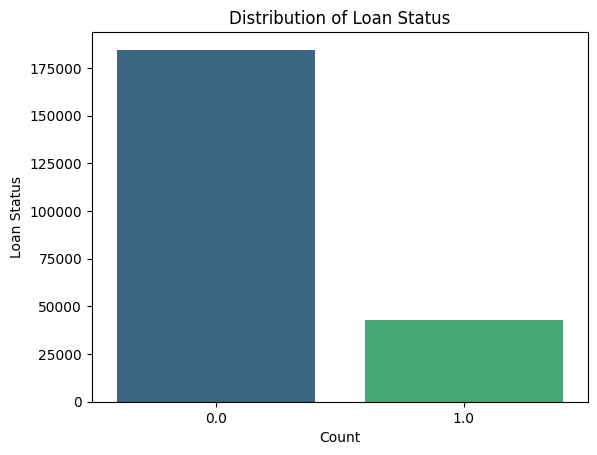

loan_status
0.0    81.14
1.0    18.86
Name: proportion, dtype: float64


In [70]:
order = df4['loan_status'].value_counts().index

sns.countplot(
    x='loan_status',
    data=df4,
    order=order,
    palette='viridis'
)

plt.title('Distribution of Loan Status')
plt.xlabel('Count')
plt.ylabel('Loan Status')

plt.show()

loan_status1 = (
    df4['loan_status']
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)
print(loan_status1)

The target variable is imbalanced, where approximately 81% of the loans are classified as Fully Paid (Good Loan), while only 19% are classified as Charged Off or Default (Bad Loan). This indicates that most borrowers successfully repay their loans, but the class imbalance should be considered during model development to avoid bias toward the majority class.

##### **Bivariat Analyst**

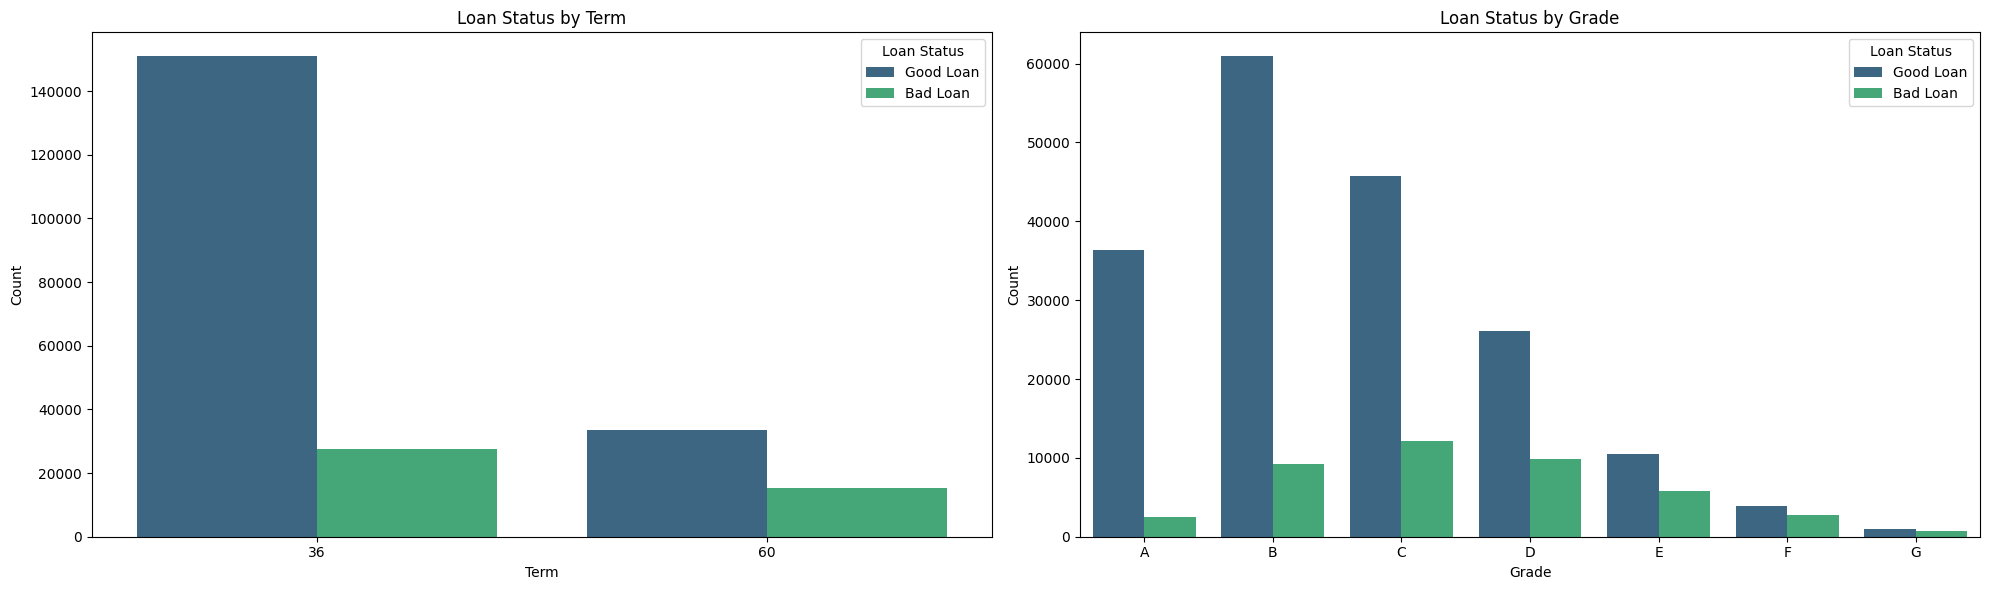

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Loan Status vs Term
sns.countplot(
    data=df4,
    x='term',
    hue='loan_status',
    palette='viridis',
    ax=axes[0]
)
handles, labels = axes[0].get_legend_handles_labels()
labels = ['Good Loan', 'Bad Loan']
axes[0].legend(handles, labels, title='Loan Status')
axes[0].set_title('Loan Status by Term')
axes[0].set_xlabel('Term')
axes[0].set_ylabel('Count')

# Loan Status vs Grade
sns.countplot(
    data=df4,
    x='grade',
    hue='loan_status',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Loan Status by Grade')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Count')
axes[1].legend(handles, labels, title='Loan Status')

plt.tight_layout()
plt.show()

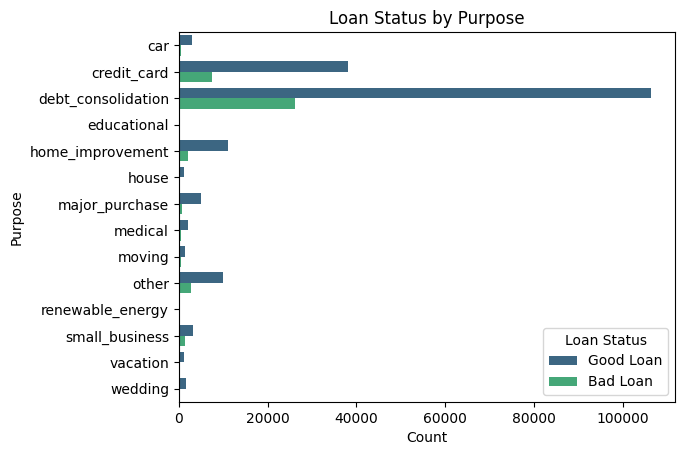

In [72]:
# Loan Status vs Purpose dan buat legen untuk good loan dan bad loan
sns.countplot(
    data=df4,
    y='purpose',
    hue='loan_status',
    palette='viridis',
)
labels = ['Good Loan', 'Bad Loan']
plt.legend(title='Loan Status', labels=labels)
plt.title('Loan Status by Purpose')
plt.xlabel('Count')
plt.ylabel('Purpose')
plt.show()



Loan Status Breakdown
* Loan Status by Term: 36-month loans have a massive volume of Good Loans compared to 60-month loans. However, 60-month loans carry a visibly higher proportion of Bad Loans relative to their total volume.

* Loan Status by Grade:  Lower risk grades (A and B) maintain highly favorable ratios with very few defaults. As the grade drops (C to G), the proportion of Bad Loans increases significantly, making lower grades much riskier.

* Loan Status by Purpose: Debt Consolidation holds the highest volume of both Good and Bad Loans by a wide margin, followed by Credit Card purposes. Other loan purposes remain minor in comparison.

Key Takeaway
⚠️ 60-month terms and lower risk grades (C through G) show a higher concentration of defaults, while Debt Consolidation remains the primary driver of overall loan volume.

/tmp/ipykernel_1186/2746826376.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1186/2746826376.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good Loan', 'Bad Loan'])
/tmp/ipykernel_1186/2746826376.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1186/2746826376.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good Loan', 'Bad Loan'])
/tmp/ipykernel_1186/2746826376.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is 

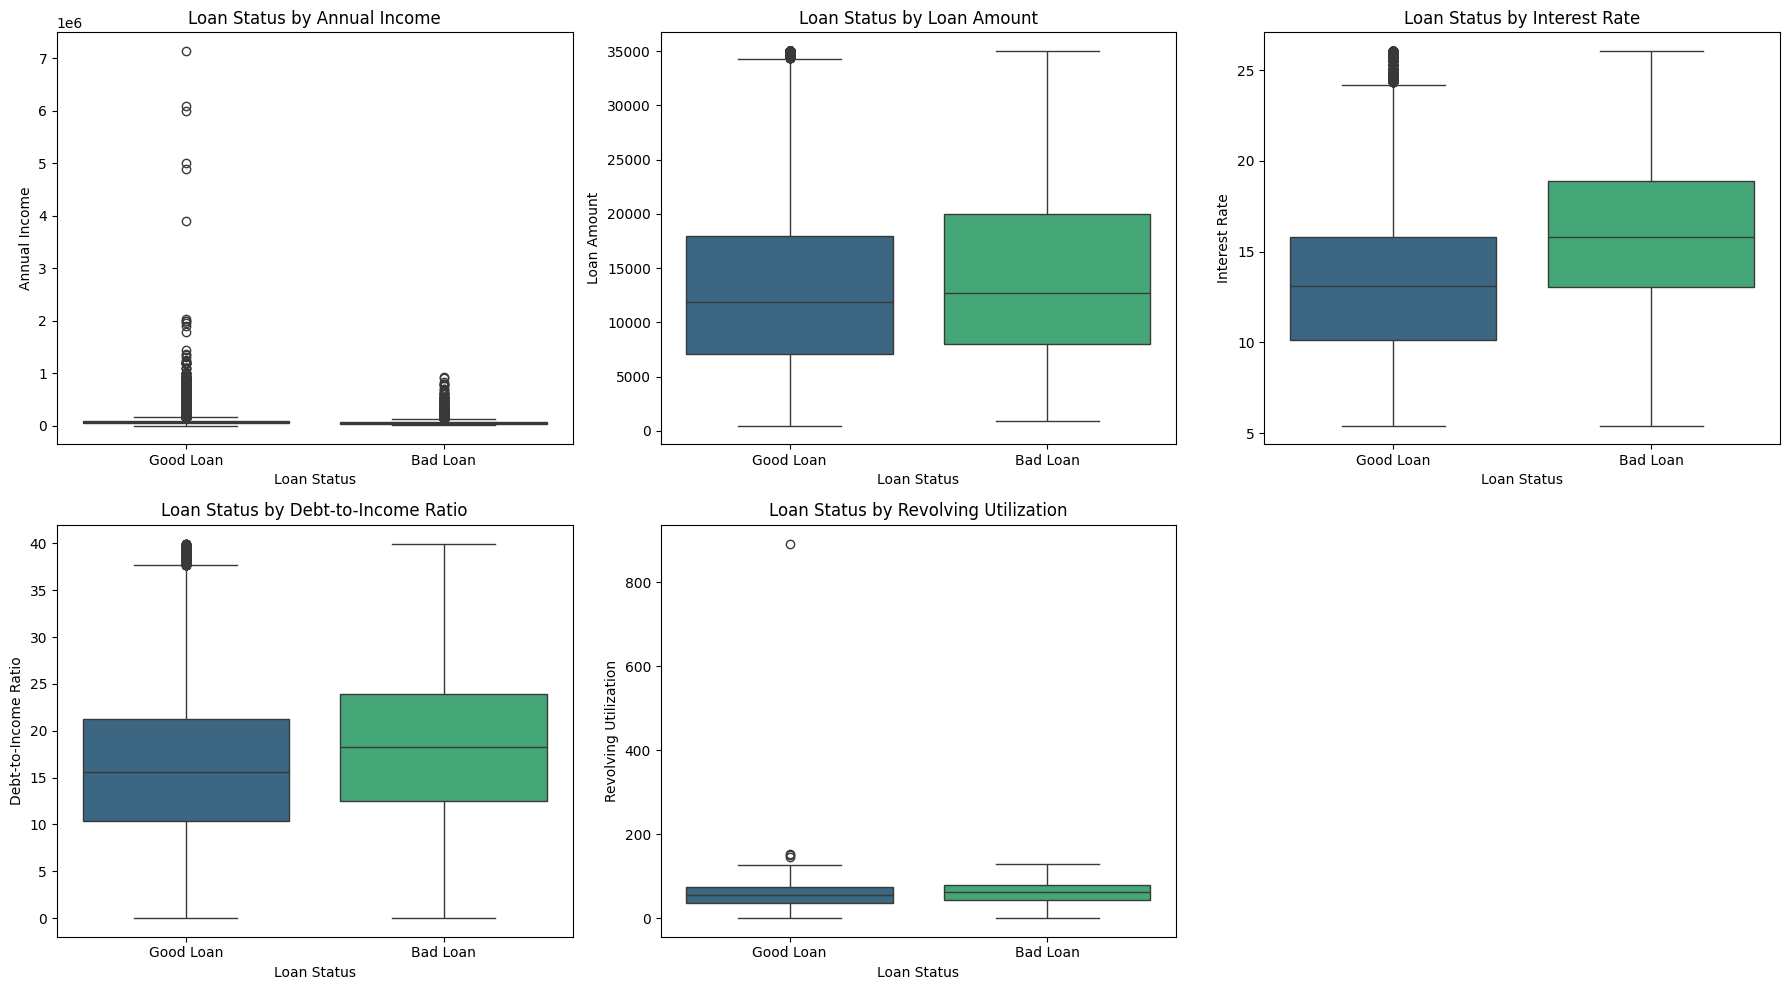

In [73]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

num_cols = [
    'annual_inc',
    'loan_amnt',
    'int_rate',
    'dti',
    'revol_util'
]

titles = [
    'Annual Income',
    'Loan Amount',
    'Interest Rate',
    'Debt-to-Income Ratio',
    'Revolving Utilization'
]

for ax, col, title in zip(axes.flatten(), num_cols, titles):
    sns.boxplot(
        data=df4,
        x='loan_status',
        y=col,
        palette='viridis',
        ax=ax
    )
    ax.set_xticklabels(['Good Loan', 'Bad Loan'])
    ax.set_title(f'Loan Status by {title}')
    ax.set_xlabel('Loan Status')
    ax.set_ylabel(title)

# Sembunyikan subplot terakhir yang kosong
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

Key Characteristics: Good vs. Bad Loans
* Annual Income: Good loan borrowers have a wider income range; bad loans are more concentrated in lower-income brackets.

* Loan Amount: Bad loans show a slightly higher median loan amount.

* Interest Rate: Strongest Indicator. Bad loans are heavily associated with higher interest rates (median ~16% vs. ~13%).

* Debt-to-Income (DTI): Bad loan borrowers carry a higher debt burden (median ~18% vs. ~15%).

* Revolving Utilization: Median rates are similar, but the good loan group contains extreme outliers (>800%).

Key Takeaway
⚠️ High interest rates and elevated DTI ratios are the two strongest predictors of loan default (Bad Loans).

## **Data Preparation**

#### **Feature Engineerinng**

##### **Encode Categorical**

In [74]:
grade_map = {
    'A':1,
    'B':2,
    'C':3,
    'D':4,
    'E':5,
    'F':6,
    'G':7
}

df4['grade'] = df4['grade'].map(grade_map).astype(int)

In [75]:
subgrade_map = {
    'A1':1,'A2':2,'A3':3,'A4':4,'A5':5,
    'B1':6,'B2':7,'B3':8,'B4':9,'B5':10,
    'C1':11,'C2':12,'C3':13,'C4':14,'C5':15,
    'D1':16,'D2':17,'D3':18,'D4':19,'D5':20,
    'E1':21,'E2':22,'E3':23,'E4':24,'E5':25,
    'F1':26,'F2':27,'F3':28,'F4':29,'F5':30,
    'G1':31,'G2':32,'G3':33,'G4':34,'G5':35
}

df4['sub_grade'] = df4['sub_grade'].map(subgrade_map).astype(int)

In [76]:
df4['term'] = df4['term'].map({
    36:0,
    60:1
})

In [77]:
cat_cols = [
    'home_ownership',
    'verification_status',
    'purpose',
    'application_type',
    'initial_list_status'
]

df4 = pd.get_dummies(
    df4,
    columns=cat_cols,
    drop_first=True
)

**using one hot encoding on categorical data types that do not have a sequence, and using mapping group for data that has a sequence**

##### **Feature Selection**

###### **Drop Feature**

In [78]:
leakage_cols = [
'recoveries','collection_recovery_fee',
'total_rec_prncp','total_pymnt','total_pymnt_inv',
'last_pymnt_amnt','out_prncp','out_prncp_inv',
'total_rec_int','total_rec_late_fee','last_pymnt_d','policy_code','addr_state','pymnt_plan',
'loan_amnt','funded_amnt_inv','installment','issue_d','earliest_cr_line','last_credit_pull_d'
]

df4.drop(columns=leakage_cols, inplace=True)

###### **Correlation**

In [79]:
df4.corr()['loan_status'].sort_values(ascending=False)
print(df4.corr()['loan_status'].sort_values(ascending=False))

loan_status                            1.000000
int_rate                               0.244765
sub_grade                              0.243652
grade                                  0.237929
term                                   0.165346
dti                                    0.118426
revol_util                             0.094673
funded_amnt                            0.065530
verification_status_Verified           0.057863
inq_last_6mths                         0.055303
home_ownership_RENT                    0.044764
purpose_small_business                 0.038037
purpose_debt_consolidation             0.026959
delinq_2yrs                            0.020105
open_acc                               0.019513
verification_status_Source Verified    0.018958
purpose_other                          0.016926
initial_list_status_w                  0.014754
pub_rec                                0.008296
purpose_moving                         0.007301
acc_now_delinq                         0

###### **Multicolinearity**

In [80]:
#multicolinearity

df_vif = df4.select_dtypes(include=['number']).astype(float)
vif = pd.DataFrame()
vif["feature"] = df_vif.columns
vif["VIF"] = [
    variance_inflation_factor(df_vif.values, i)
    for i in range(df_vif.shape[1])
]
vif.sort_values("VIF", ascending=False)

,feature,VIF
3,grade,115.695712
4,sub_grade,99.210849
2,int_rate,80.575265
10,open_acc,12.151956
14,total_acc,10.927186
13,revol_util,8.255605
7,dti,7.313012
0,funded_amnt,5.589786
5,annual_inc,3.555614
12,revol_bal,2.267004


###### **Result**

In [81]:
#Drop Feature Grade dan Sub Grade
df4.drop(columns=['grade', 'sub_grade'], inplace=True)

##### **Handling Outlier**

In [82]:
#handling outlier
num_cols = df4.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    q1 = df4[col].quantile(0.01)
    q3 = df4[col].quantile(0.99)

    df4[col] = df4[col].clip(lower=q1, upper=q3)

**Using IQR 1% and 99%, with the aim of only limiting extreme values**

In [83]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 227411 entries, 0 to 466283
Data columns (total 36 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   funded_amnt                          227411 non-null  int64  
 1   term                                 227411 non-null  int64  
 2   int_rate                             227411 non-null  float64
 3   annual_inc                           227411 non-null  float64
 4   loan_status                          227411 non-null  float64
 5   dti                                  227411 non-null  float64
 6   delinq_2yrs                          227411 non-null  float64
 7   inq_last_6mths                       227411 non-null  float64
 8   open_acc                             227411 non-null  float64
 9   pub_rec                              227411 non-null  float64
 10  revol_bal                            227411 non-null  float64
 11  revol_util        

### **Split Data**

In [84]:
X = df4.drop('loan_status', axis=1)
y = df4['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [85]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Data Modelling**

### **Logistic Regression**

In [86]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

### **Random Forest**

In [87]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

### **XGBoost**

In [88]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

### **Cross Validation**

#### **Logistic Regression**

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print(scores)
print("Mean ROC-AUC:", scores.mean())

[0.70414862 0.70351627 0.70587396 0.7046129  0.70503512]
Mean ROC-AUC: 0.7046373725174243


#### **Random Forest**

In [90]:
from sklearn.model_selection import cross_val_score

scores1 = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("Mean ROC-AUC:", scores1.mean())

Mean ROC-AUC: 0.6985561326452738


#### **XGBoost**

In [91]:
from sklearn.model_selection import cross_val_score

scores2 = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("Mean ROC-AUC:", scores2.mean())

Mean ROC-AUC: 0.6945552860678845


### **HyperParameter Tuning**

In [92]:
param_grid = {
    'C':[10],
    'penalty':['l2']
}

grid_log = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_log.fit(X_train, y_train)

print(grid_log.best_params_)
print(grid_log.best_score_)

{'C': 10, 'penalty': 'l2'}
0.6585147062789132


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [93]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[100],
    'max_depth':[10],
    'min_samples_split':[5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
0.7064197722505957


In [94]:
param_grid = {
    'n_estimators':[100],
    'max_depth':[5],
    'min_samples_split':[2]
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print(grid_xgb.best_params_)
print(grid_xgb.best_score_)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:37:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
0.7068285745428555


In [96]:
#test model underfitting atau overfitting
from sklearn.metrics import roc_auc_score
#import f1 score
from sklearn.metrics import f1_score
#import confusion matrix
from sklearn.metrics import confusion_matrix
#import classification report
from sklearn.metrics import classification_report

models = {
    "Logistic Regression":log_model,
    "Random Forest":rf_model,
    "XGBoost":xgb_model
}

results = []

for name, model in models.items():

    # Train
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:,1]

    # Test
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:,1]

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)

    gap = train_acc - test_acc

    if train_acc < 0.70 and test_acc < 0.70:
        status = "Underfitting"
    elif gap > 0.10:
        status = "Overfitting"
    else:
        status = "Good Fit"

    results.append({
        "Model": name,
        "Train Accuracy": round(train_acc,4),
        "Test Accuracy": round(test_acc,4),
        "Train ROC-AUC": round(train_auc,4),
        "Test ROC-AUC": round(test_auc,4),
        "Precision": round(precision_score(y_test, y_test_pred),4),
        "Recall": round(recall_score(y_test, y_test_pred),4),
        "F1 Score": round(f1_score(y_test, y_test_pred),4),
        "Status": status
    })

results_df = pd.DataFrame(results)
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric

,Model,Train Accuracy,Test Accuracy,Train ROC-AUC,Test ROC-AUC,Precision,Recall,F1 Score,Status
0,Logistic Regression,0.8114,0.8114,0.5000,0.5000,0.0000,0.0000,0.0000,Good Fit
1,Random Forest,1.0000,0.8118,1.0000,0.6960,0.5109,0.0437,0.0805,Overfitting
2,XGBoost,0.8389,0.8087,0.8317,0.6953,0.4621,0.0880,0.1479,Good Fit


**Logistic Regression failed on minority classes ($0.00$ metrics), Random Forest suffered from severe overfitting, and only XGBoost achieved a Good Fit.**

## **Evaluation**

In [97]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression":log_model,
    "Random Forest":rf_model,
    "XGBoost":xgb_model
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    if hasattr(model,"predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.predict(X_test)

    print("="*40)
    print(name)

    print("Accuracy :",accuracy_score(y_test,y_pred))
    print("Precision:",precision_score(y_test,y_pred))
    print("Recall   :",recall_score(y_test,y_pred))
    print("F1 Score :",f1_score(y_test,y_pred))
    print("ROC-AUC  :",roc_auc_score(y_test,y_prob))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression
Accuracy : 0.8114020623089946
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.5
Random Forest
Accuracy : 0.8117538420948486
Precision: 0.510899182561308
Recall   : 0.043716484028911165
F1 Score : 0.08054123711340207
ROC-AUC  : 0.6960301270719319
XGBoost
Accuracy : 0.8086757689686256
Precision: 0.4620563035495716
Recall   : 0.08801585451154115
F1 Score : 0.14786525656090874
ROC-AUC  : 0.6953155829864313


In [98]:
#evaluasi 3 model yang menggunakan hyperparameter tuning
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
models = {
    "Logistic Regression":grid_log,
    "Random Forest":grid_rf,
    "XGBoost":grid_xgb
}
for name, model in models.items():
    y_pred = model.predict(X_test)
    if hasattr(model,"predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.predict(X_test)
    print("="*40)
    print(name)
    print("Accuracy :",accuracy_score(y_test,y_pred))
    print("Precision:",precision_score(y_test,y_pred))
    print("Recall   :",recall_score(y_test,y_pred))
    print("F1 Score :",f1_score(y_test,y_pred))
    print("ROC-AUC  :",roc_auc_score(y_test,y_prob))

Logistic Regression
Accuracy : 0.8113580898357629
Precision: 0.4852941176470588
Recall   : 0.003847050594544183
F1 Score : 0.007633587786259542
ROC-AUC  : 0.6177410830534147
Random Forest
Accuracy : 0.8113800760723787
Precision: 0.4956521739130435
Recall   : 0.006644905572394498
F1 Score : 0.01311399976992983
ROC-AUC  : 0.702814025121498
XGBoost
Accuracy : 0.8117098696216168
Precision: 0.5059726962457338
Recall   : 0.06913033341105153
F1 Score : 0.12164102564102564
ROC-AUC  : 0.7046642525064433


In [99]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
models = {
    "Logistic Regression":grid_log,
    "Random Forest":grid_rf,
    "XGBoost":grid_xgb
}

results = []

for name, model in models.items():

    # Train
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:,1]

    # Test
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:,1]

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)

    gap = train_acc - test_acc

    if train_acc < 0.70 and test_acc < 0.70:
        status = "Underfitting"
    elif gap > 0.10:
        status = "Overfitting"
    else:
        status = "Good Fit"

    results.append({
        "Model": name,
        "Train Accuracy": round(train_acc,4),
        "Test Accuracy": round(test_acc,4),
        "Train ROC-AUC": round(train_auc,4),
        "Test ROC-AUC": round(test_auc,4),
        "Precision": round(precision_score(y_test, y_test_pred),4),
        "Recall": round(recall_score(y_test, y_test_pred),4),
        "F1 Score": round(f1_score(y_test, y_test_pred),4),
        "Status": status
    })

results_df = pd.DataFrame(results)
results_df

,Model,Train Accuracy,Test Accuracy,Train ROC-AUC,Test ROC-AUC,Precision,Recall,F1 Score,Status
0,Logistic Regression,0.8111,0.8114,0.6210,0.6177,0.4853,0.0038,0.0076,Good Fit
1,Random Forest,0.8136,0.8114,0.7455,0.7028,0.4957,0.0066,0.0131,Good Fit
2,XGBoost,0.8204,0.8117,0.7571,0.7047,0.5060,0.0691,0.1216,Good Fit


Hyperparameter tuning successfully brought all models to a Good Fit status, fixing overfitting and zero-value metric issues.


Why XGBoost is the Best Model?
* Stable Good Fit: Maintains high consistency with a minimal gap between train and test accuracy (~82% vs. ~81.17%).

* Highest ROC-AUC: Delivers the best class separation with the highest Test ROC-AUC score (0.7047).

* Superior Metrics: Outperforms other models by capturing the highest Recall (0.0691) and F1-Score (0.1216).

In [107]:
#feature importance
import numpy as np
import pandas as pd

# ==========================
# Fit GridSearch
# ==========================
grid_log.fit(X_train, y_train)
grid_rf.fit(X_train, y_train)
grid_xgb.fit(X_train, y_train)

# ==========================
# Ambil model terbaik
# ==========================
best_log = grid_log.best_estimator_
best_rf = grid_rf.best_estimator_
best_xgb = grid_xgb.best_estimator_

# ==========================
# Feature Importance
# ==========================

# Logistic Regression
log_importance = np.abs(best_log.coef_[0])

# Random Forest
rf_importance = best_rf.feature_importances_

# XGBoost
xgb_importance = best_xgb.feature_importances_

# ==========================
# DataFrame
# ==========================
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Logistic Regression': log_importance,
    'Random Forest': rf_importance,
    'XGBoost': xgb_importance
})

importance_df = importance_df.sort_values(
    by='Logistic Regression',
    ascending=False
)

print(importance_df.head(10))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:13:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                       Feature  Logistic Regression  Random Forest   XGBoost
1                         term             0.276885       0.151210  0.147132
18         home_ownership_RENT             0.171912       0.012132  0.037190
14     home_ownership_MORTGAGE             0.129410       0.011168  0.015637
22  purpose_debt_consolidation             0.126710       0.002968  0.020261
21         purpose_credit_card             0.123635       0.004119  0.021532
6               inq_last_6mths             0.117734       0.020215  0.022650
5                  delinq_2yrs             0.086827       0.009266  0.019308
17          home_ownership_OWN             0.056927       0.002738  0.019614
7                     open_acc             0.053674       0.022261  0.018282
11                   total_acc             0.042020       0.030196  0.018759


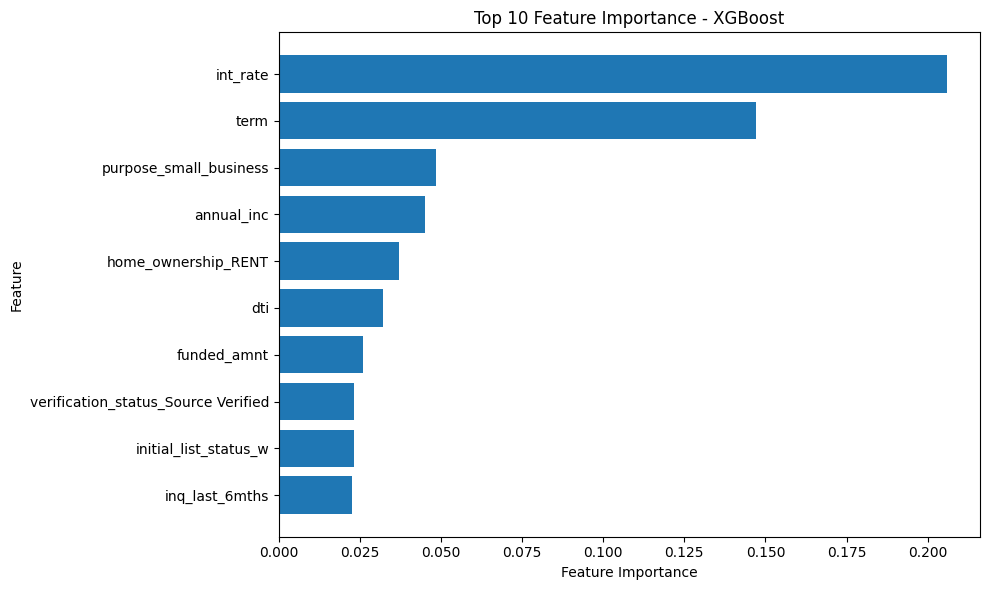

In [106]:
import pandas as pd
import matplotlib.pyplot as plt

# Ambil model terbaik hasil GridSearchCV
best_xgb = grid_xgb.best_estimator_

# Feature importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
})

# Urutkan dari terbesar
importance = importance.sort_values(by='Importance', ascending=True)

# Plot Top 10
top10 = importance.tail(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

* Top 2 Predictors: Interest Rate (int_rate) and Loan Term (term) are by far the most dominant factors influencing the model's decisions.

* Key Financial Drivers: Purpose (Small Business), Annual Income (annual_inc), and Debt-to-Income (dti) also play critical roles in risk assessment.

* Other Noteworthy Features: Home Ownership (Rent) and Funded Amount (funded_amnt) show moderate importance, while verification and inquiry metrics have minor influence.